# interpolación: Polinomial Simple


Construir un polinomio de máximo grado que contenga el siguiente conjunto de datos:

|dia        | 0   |6  |
|---        |-----|---|
|Muestra(mg)| 6.67|17.33|

Para aproximar el peso de una larva en el 4 dia de crecimiento

In [1]:
import numpy as np
import sel as sel
import matplotlib.pyplot as plt

A = np.array([[1,0],[1,6]], float)
b = np.array([6.67, 17.33], float)

coef_pol = sel.eliminacion_DD(A, b)
print(coef_pol)
p = lambda x: coef_pol[0] + coef_pol[1] * x

[6.67       1.77666667]


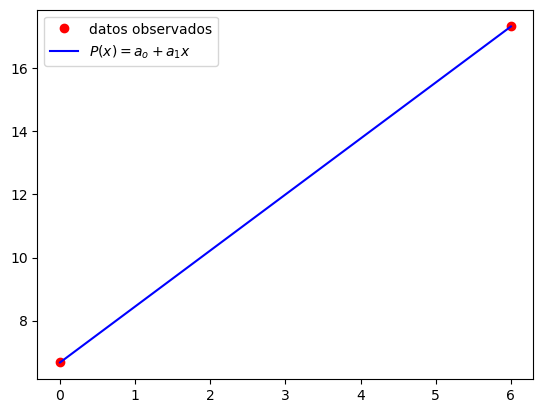

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sel as sel

A= np.array([[1,0],[1,6]],float)
b= np.array([6.67,17.33],float)
a_i=sel.eliminacion_DD(A,b)

x_data = np.array([0, 6])
y_data = np.array([6.67, 17.33])

P=lambda x:a_i[0]+a_i[1]*x


ux = np.linspace(min(x_data), max(x_data), 10)
plt.plot(x_data, y_data, 'or', label='datos observados')
plt.plot(ux, P(ux), 'b', label='$P(x)=a_o+a_1x$')
plt.legend()
plt.show()

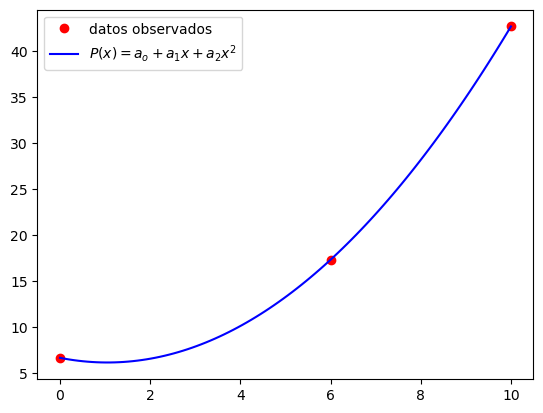

El peso de la larva en el dia 4 es 10.130008


In [3]:
import numpy as np
import sel as sel
import matplotlib.pyplot as plt

# A = np.array([[1,0],[1,6]])
# b = np.array([6.67, 17.33])
x_data = np.array([0, 6, 10])
y_data = np.array([6.67, 17.33, 42.67])
# coef_pol = sel.Eliminacion_DD(A, b)

P2 = lambda x: 6.67 - 0.95833*x + 0.455833*x**2

ux = np.linspace(min(x_data), max(x_data), 100)
plt.plot(x_data, y_data, 'or', label='datos observados')
plt.plot(ux, P2(ux), 'b', label='$P(x)=a_o+a_1x+a_2x^2$')
plt.legend()
plt.show()

print(f'El peso de la larva en el dia 4 es {P2(4)}')

In [4]:
x_data = np.array([0, 6 ,10, 13, 17, 20, 28], float)
y_data = np.array([6.67, 17.33, 42.67, 37.33, 30.10, 29.31, 28.74])

def Matrix(x_data):
    n = len(x_data)
    A = np.zeros([n,n])
    A[0:n,0] = 1.0
    for j in range(1, n):
        for i in range(0, n):
            A[i,j] = A[i, j-1]*x_data[i]
    return A

A = Matrix(x_data)
print(A)

[[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.00000000e+00 6.00000000e+00 3.60000000e+01 2.16000000e+02
  1.29600000e+03 7.77600000e+03 4.66560000e+04]
 [1.00000000e+00 1.00000000e+01 1.00000000e+02 1.00000000e+03
  1.00000000e+04 1.00000000e+05 1.00000000e+06]
 [1.00000000e+00 1.30000000e+01 1.69000000e+02 2.19700000e+03
  2.85610000e+04 3.71293000e+05 4.82680900e+06]
 [1.00000000e+00 1.70000000e+01 2.89000000e+02 4.91300000e+03
  8.35210000e+04 1.41985700e+06 2.41375690e+07]
 [1.00000000e+00 2.00000000e+01 4.00000000e+02 8.00000000e+03
  1.60000000e+05 3.20000000e+06 6.40000000e+07]
 [1.00000000e+00 2.80000000e+01 7.84000000e+02 2.19520000e+04
  6.14656000e+05 1.72103680e+07 4.81890304e+08]]


# Ejercicio

Se sospecha que las grandes cantidades de tanino en las hojas maduras de los robles inhiben el crecimiento de la larva de 

polilla de invierno (Operophtera bromata L., Geometridae) que daña en exceso estos árboles en ciertos años. La siguiente tabla enumera el peso promedio de dos muestras de la larva en los primeros 28 días después de su nacimiento. Mientras la primera muestra se crió en las hojas jóvenes de roble, la segunda muestra se crió en las hojas maduras.



|	Día	|  	0	|	 6 	|	10	 |	13	|	17	|	20	|	28	|
|---------------|---------------|---------------|----------------|--------------|---------------|---------------|---------------|
|muestra 1 (mg) |	6.67	|	17.33	|	42.67    |	 37.33	|	30.10	|	29.31	|    28.74 	|
|muestra 2(mg)  |	6.67	|	16.11	|	18.89	 |	15.00	|	10.56	|9.44		|	8.89	|



1\. Construir un polinomio para obtener la curva de peso promedio para cada muestra

2\. Encuentre un peso promedio máximo aproximado para cada muestra( determinando el máximo del polinomio, usando un método de ceros de funciones)


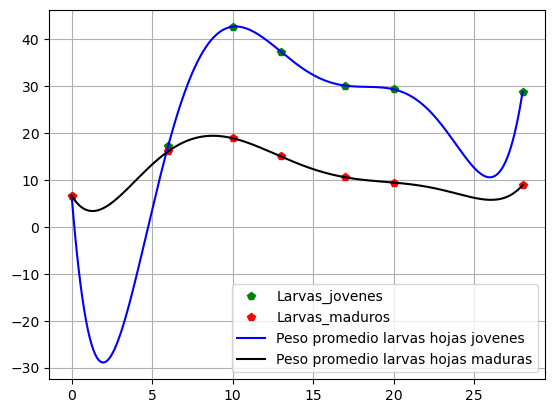

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sel as sl
import modelos as m

dias = np.array([0, 6 ,10, 13, 17, 20, 28], float)
# Hojas jovenes
peso_joven = np.array([6.67, 17.33, 42.67, 37.33, 30.10, 29.31, 28.74])
# Hojas maduras
peso_maduro = np.array([6.67, 16.11, 18.89,	15.00, 10.56, 9.44, 8.89])
A = m.Matrix(dias)
coeficiente_1 = sl.eliminacion_DD(A, peso_joven)
coeficiente_2 = sl.eliminacion_DD(A, peso_maduro)
u_dias = np.linspace(min(dias), max(dias), 500)
P_joven = lambda x: sum(coeficiente_1[i] * (x**i) for i in range(len(dias)))
P_maduro = lambda x: sum(coeficiente_2[i] * (x**i) for i in range(len(dias)))

plt.plot(dias, peso_joven, 'gp', label='Larvas_jovenes')
plt.plot(dias, peso_maduro, 'rp', label='Larvas_maduros')
plt.plot(u_dias, P_joven(u_dias), 'b', label='Peso promedio larvas hojas jovenes')
plt.plot(u_dias, P_maduro(u_dias), 'k', label='Peso promedio larvas hojas maduras')
plt.legend()
plt.grid()
plt.show()

In [6]:
import sympy as sp
import ceros as Zero

x = sp.symbols('x')
P_joven = sum(coeficiente_1[i] * (x**i) for i in range(len(dias)))
P_madura = sum(coeficiente_1[i] * (x**i) for i in range(len(dias)))
dias_max = Zero.Newton(sp.diff(P_joven, x), 10, 1e-6)
print(f'El dia en el alcanza  el peso promedio es {dias_max} y su valor es {P_joven.evalf(subs={x: dias_max})}g')

El dia en el alcanza  el peso promedio es 10.188529765161544 y su valor es 42.7084211919494g


Hallar el ceros de P(x)  a partir de los siguientes datos; 


|x 	|0	| 0.5	| 1 	|1.5 	|2 	|2.5	 | 3	   |
|-------|-------|-------|-------|-------|-------|--------|---------|
|y	| 1.8421| 2.4694| 2.4921| 1.9047| 0.8509| −0.4112| −1.5727|



Utiliza la interpolacioón polinomial simple sobre:

- Usando 3 puntos de datos vecinos más cercanos
- Usando 4 puntos de datos vecinos más cercanos 